In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [2]:
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [3]:
def first_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence"""
    state["final"] = f"Hi {state['name']}!"
    return state

def second_node(state: AgentState) -> AgentState:
    """This is the second node of our sequence"""
    state["final"] += f" You are {state['age']} years old."
    return state

In [4]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "second_node")
graph.set_finish_point("second_node")

app = graph.compile()

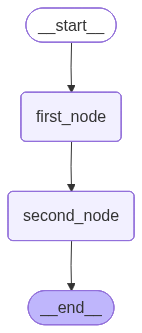

In [5]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
result = app.invoke({"name": "PuLeeNa", "age": "24"})
print(result)

{'name': 'PuLeeNa', 'age': '24', 'final': 'Hi PuLeeNa! You are 24 years old.'}


Exercise

In [7]:
class AgentState(TypedDict):
    name: str
    age: str
    skills: List[str]
    result: str

In [8]:
def first_node(state: AgentState) -> AgentState:
    """This node takes the name, and creates a greeting."""
    state['result'] = f"Hi {state['name']}, welcome! "
    return state

def second_node(state: AgentState) -> AgentState:
    """This node takes the age, describes it"""
    state['result'] += f"You are {state['age']} years old! "
    return state

def third_node(state: AgentState) -> AgentState:
    """This node takes skills, and adds it to the result."""
    skills_str = ", ".join(state['skills'])
    state['result'] += f"Your skills are: {skills_str}."
    return state

In [9]:
graph = StateGraph(AgentState)

graph.add_node("first", first_node)
graph.add_node("second", second_node)
graph.add_node("third", third_node)

graph.set_entry_point("first")
graph.add_edge("first", "second")
graph.add_edge("second", "third")
graph.set_finish_point("third")

app = graph.compile()

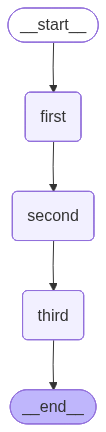

In [10]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
res = app.invoke({"name": "PuLeeNa", "age": "24", "skills": ["Python", "AI", "LangGraph"]})
res['result']

'Hi PuLeeNa, welcome! You are 24 years old! Your skills are: Python, AI, LangGraph.'